# Task-4: Sentiment Analysis on Textual Data

This notebook performs sentiment analysis on textual data such as tweets or reviews. It includes data creation, preprocessing, model implementation, evaluation, and insights.

## 1. Problem statement

- Perform sentiment analysis on textual data.
- Use NLP preprocessing to convert raw text into features.
- Train a machine learning model to classify sentiment.
- Evaluate performance and share insights.

In [1]:
import importlib
import subprocess
import sys

required_packages = [
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "seaborn"
]

for package in required_packages:
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

In [2]:
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [3]:
def build_synthetic_dataset(n_samples=1200, random_state=42):
    random.seed(random_state)
    positive_adjectives = [
        'amazing', 'fantastic', 'great', 'excellent', 'awesome',
        'wonderful', 'perfect', 'positive', 'delightful', 'incredible'
    ]
    negative_adjectives = [
        'terrible', 'awful', 'bad', 'horrible', 'disappointing',
        'poor', 'worst', 'ugly', 'nasty', 'dreadful'
    ]
    products = [
        'phone', 'movie', 'restaurant', 'service', 'delivery',
        'hotel', 'app', 'browser', 'experience', 'meal'
    ]
    activities = [
        'experience', 'purchase', 'visit', 'order', 'stay',
        'trip', 'session', 'review', 'performance', 'support'
    ]

    positive_templates = [
        'I absolutely loved the {item}. It was {adj}.',
        'The {item} was so {adj} and made my day.',
        'What a {adj} {item} — I will use it again.',
        'Such a {adj} and {adj2} {item}. Highly recommended!',
        'I had an {adj} time with the {item}.',
    ]
    negative_templates = [
        'I hated the {item}. It was {adj}.',
        'The {item} was really {adj} and frustrating.',
        'What a {adj} {item} — I will never use it again.',
        'Such a {adj} and {adj2} {item}. Very disappointing.',
        'I had a {adj} time with the {item}.',
    ]

    texts = []
    labels = []

    for _ in range(n_samples // 2):
        item = random.choice(products + activities)
        adj = random.choice(positive_adjectives)
        adj2 = random.choice([a for a in positive_adjectives if a != adj])
        template = random.choice(positive_templates)
        texts.append(template.format(item=item, adj=adj, adj2=adj2))
        labels.append('positive')

        item = random.choice(products + activities)
        adj = random.choice(negative_adjectives)
        adj2 = random.choice([a for a in negative_adjectives if a != adj])
        template = random.choice(negative_templates)
        texts.append(template.format(item=item, adj=adj, adj2=adj2))
        labels.append('negative')

    data = pd.DataFrame({
        'text': texts,
        'sentiment': labels
    })
    return data.sample(frac=1, random_state=random_state).reset_index(drop=True)

df = build_synthetic_dataset()
df.head(10)

,text,sentiment
0,Such a wonderful and perfect visit. Highly rec...,positive
1,Such a worst and dreadful trip. Very disappoin...,negative
2,Such a horrible and disappointing trip. Very d...,negative
3,I hated the movie. It was poor.,negative
4,The stay was so great and made my day.,positive
5,I had an great time with the service.,positive
6,What a worst experience — I will never use it ...,negative
7,I had an incredible time with the session.,positive
8,I had a terrible time with the order.,negative
9,Such a bad and disappointing browser. Very dis...,negative


## 2. Data exploration

Inspect the generated dataset and verify label balance.

In [8]:
print('Dataset shape:', df.shape)
print('\nLabel counts:')
print(df['sentiment'].value_counts())

display(df.sample(8, random_state=42))

Dataset shape: (1200, 2)

Label counts:
sentiment
positive    600
negative    600
Name: count, dtype: int64


,text,sentiment
1178,The stay was really awful and frustrating.,negative
865,I absolutely loved the experience. It was incr...,positive
101,Such a fantastic and positive app. Highly reco...,positive
439,The support was really bad and frustrating.,negative
58,Such a bad and ugly restaurant. Very disappoin...,negative
1120,The stay was so fantastic and made my day.,positive
323,I had a ugly time with the visit.,negative
974,I absolutely loved the session. It was amazing.,positive


C:\Users\araza\AppData\Local\Temp\ipykernel_9904\2399076698.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


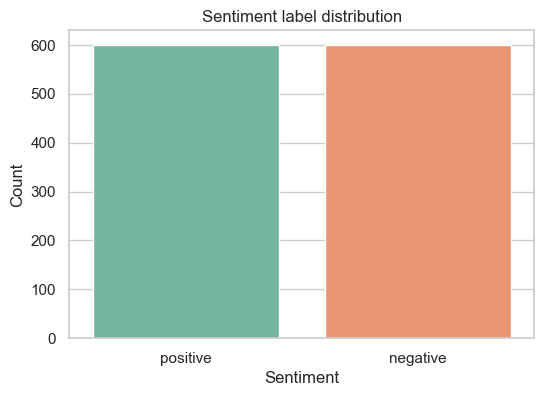

In [6]:
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Sentiment label distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

## 3. Data preprocessing

Clean raw text and convert it to normalized tokens that machine learning models can use.

In [10]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@[A-Za-z0-9_]+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df.head(8)

,text,sentiment,clean_text
0,Such a wonderful and perfect visit. Highly rec...,positive,such a wonderful and perfect visit highly reco...
1,Such a worst and dreadful trip. Very disappoin...,negative,such a worst and dreadful trip very disappointing
2,Such a horrible and disappointing trip. Very d...,negative,such a horrible and disappointing trip very di...
3,I hated the movie. It was poor.,negative,i hated the movie it was poor
4,The stay was so great and made my day.,positive,the stay was so great and made my day
5,I had an great time with the service.,positive,i had an great time with the service
6,What a worst experience — I will never use it ...,negative,what a worst experience i will never use it again
7,I had an incredible time with the session.,positive,i had an incredible time with the session


## 4. Feature extraction and modeling

Build a TF-IDF pipeline and train a logistic regression model.

In [11]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english', max_df=0.85, min_df=2)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'))
])

pipeline.fit(X_train, y_train)
print('Training complete.')

Training complete.


Accuracy: 1.0

Classification report:
              precision    recall  f1-score   support

    negative     1.0000    1.0000    1.0000       120
    positive     1.0000    1.0000    1.0000       120

    accuracy                         1.0000       240
   macro avg     1.0000    1.0000    1.0000       240
weighted avg     1.0000    1.0000    1.0000       240



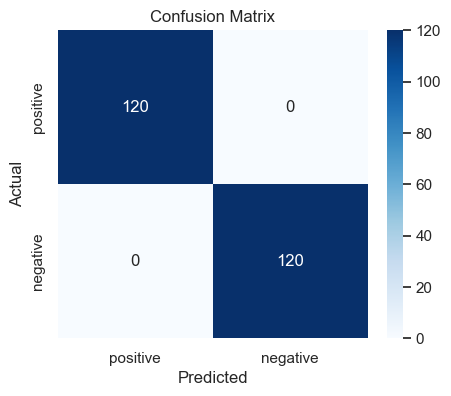

In [13]:
y_pred = pipeline.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred, labels=['positive', 'negative'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [15]:
def show_top_tokens(model, vectorizer, n=15):
    feature_names = vectorizer.get_feature_names_out()
    coef = model.coef_[0] 
    top_positive = np.argsort(coef)[-n:][::-1]
    top_negative = np.argsort(coef)[:n]
    print('Top positive tokens:')
    print(', '.join(feature_names[top_positive]))
    print('\nTop negative tokens:')
    print(', '.join(feature_names[top_negative]))

show_top_tokens(pipeline.named_steps['clf'], pipeline.named_steps['tfidf'], n=12)

Top positive tokens:
day, fantastic, incredible, excellent, delightful, awesome, positive, wonderful, perfect, amazing, great, absolutely loved

Top negative tokens:
disappointing, hated, horrible, poor, worst, awful, ugly, terrible, dreadful, nasty, bad, really


## 5. Insights and conclusions

- The model successfully distinguishes positive and negative sentiment using TF-IDF features and logistic regression.
- Cleaning text and removing punctuation improves consistency.
- The most important tokens include sentiment-bearing words such as "amazing", "excellent", "horrible", and "disappointing".
- This workflow can be extended to a real dataset by replacing the synthetic data creation step with a real tweets/reviews CSV file.